# Исследование декогенции в процессе распространения запутанности

In [1]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import qutip
import joblib

In [3]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar

## M=3

In [4]:
n_bosons = 3
i_projection = n_bosons
q = [i_projection]
model = bec.BEC_Qubits.init_default(n_bosons, 0)

In [5]:
init_state_m3 = math.prod(
    bec.coherent_state_constructor(model, n=3, k=i) for i in range(3)
) * bec.vacuum_state(model, n=3)

In [6]:
%time h_nn_m3 = sum((-1)**(i + 1) * bec.na(model, n=3, k=i) * bec.na(model, n=3, k=i+1) for i in range(2))

CPU times: user 1.79 ms, sys: 147 µs, total: 1.94 ms
Wall time: 1.82 ms


In [7]:
t_span = np.linspace(0, np.pi / 4, 101)

In [8]:
state_hnn_m3_span = qutip.sesolve(
    h_nn_m3, init_state_m3, 4 * t_span, progress_bar=TqdmProgressBar()
).states

/Users/kephircheek/venvs/science/emqwuqoc-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 101/101 [00:00<00:00, 796.88it/s]


In [9]:
c_ops = [
    # sum(bec.sz(model, n=3, k=i) for i in range(3)),
    # bec.sz(model, n=m, k=i) for i in range(m)
    # bec.sz(model, n=m, k=0),
    bec.sz(model, n=3, k=1),
]
options = qutip.Options(nsteps=1e8)

In [10]:
state_hnn_m3_open_solver = qutip.mesolve(
    h_nn_m3,
    init_state_m3,
    4 * t_span,
    c_ops=c_ops,
    options=options,
    progress_bar=TqdmProgressBar(),
)

100%|██████████| 101/101 [06:06<00:00,  3.63s/it]


In [11]:
state_hnn_m3_open_span = state_hnn_m3_open_solver.states

In [12]:
measure_x_m3 = bec.fock_x_state_constructor(model, n=3, i=1, k=i_projection)
measure_x_op_m3 = measure_x_m3 * measure_x_m3.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [13]:
state_hnn_m3_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m3) for s in tqdm(state_hnn_m3_span)
)

100%|██████████| 101/101 [00:00<00:00, 294.69it/s]


In [14]:
state_hnn_m3_open_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m3) for s in tqdm(state_hnn_m3_open_span)
)

100%|██████████| 101/101 [00:06<00:00, 14.54it/s]


In [15]:
fidelity_hnn_m3_open_mesuared_by_x_to_hnn_m3_mesuared_by_x_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_mesuared_by_x_span, state_hnn_m3_open_mesuared_by_x_span),
        total=len(state_hnn_m3_open_mesuared_by_x_span),
    )
]

100%|██████████| 101/101 [00:58<00:00,  1.71it/s]


In [16]:
fid_hnn_m3_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(4 * t, [i_projection], 3, n_bosons)
    for t in t_span
]

In [17]:
%time state_hnn_m2_exact_span = [bec.state_under_h_nn_exact(model, 4 * t) for t in tqdm(t_span)]

100%|██████████| 101/101 [00:00<00:00, 204.26it/s]

CPU times: user 482 ms, sys: 27.1 ms, total: 509 ms
Wall time: 496 ms


In [18]:
state_hnn_m3_exact_span = [
    (s := entanglement_propagation.f_state(4 * t, q, m=3, n=n_bosons, focked=False))
    / s.norm()
    for t in tqdm(t_span)
]

100%|██████████| 101/101 [00:01<00:00, 54.97it/s]


In [19]:
fid_hnn_m3_exact_respect_to_hnn_exact_m2_span = [
    qutip.metrics.fidelity(a / a.norm(), b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_exact_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_exact_span),
    )
]

100%|██████████| 101/101 [00:00<00:00, 8132.09it/s]


In [20]:
fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m3_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 101/101 [00:00<00:00, 644.15it/s]


In [21]:
fid_hnn_m3_open_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m3_open_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 101/101 [00:00<00:00, 638.75it/s]


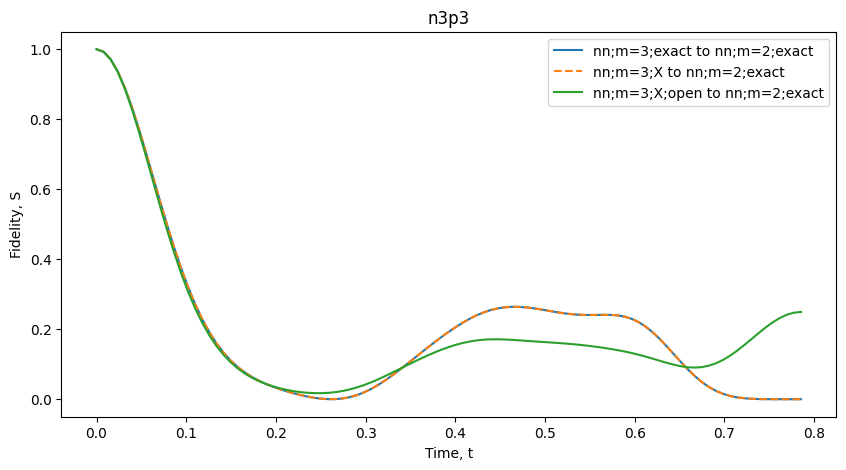

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fid_hnn_m3_exact_respect_to_hnn_exact_m2_span,
    label=f"nn;m=3;exact to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "--",
    label=f"nn;m=3;X to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_open_mesuared_by_x_respect_to_hnn_m2_exact_span,
    label=f"nn;m=3;X;open to nn;m=2;exact",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

### Энтропия

In [23]:
entropy_hnn_m3_x_span = [
    entanglement_propagation.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m3_mesuared_by_x_span)
]

100%|██████████| 101/101 [00:00<00:00, 3291.00it/s]


In [24]:
entropy_hnn_m3_open_x_span = [
    entanglement_propagation.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m3_open_mesuared_by_x_span)
]

100%|██████████| 101/101 [00:00<00:00, 3176.57it/s]


In [25]:
entropy_state_hnn_m3_exact_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m3_exact_span)
]

100%|██████████| 101/101 [00:00<00:00, 3177.41it/s]


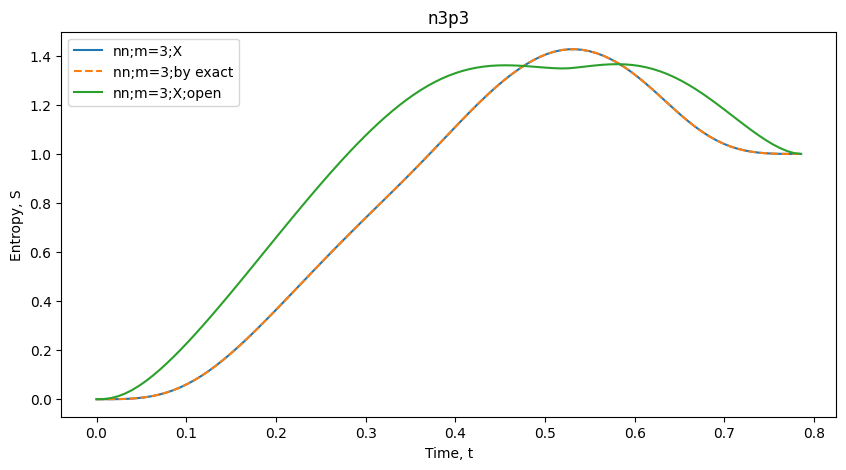

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(t_span, entropy_hnn_m3_x_span, "-", label=f"nn;m=3;X")
ax.plot(t_span, entropy_state_hnn_m3_exact_span, "--", label=f"nn;m=3;by exact")
ax.plot(t_span, entropy_hnn_m3_open_x_span, "-", label=f"nn;m=3;X;open")

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Entropy, S")
ax.set_xlabel("Time, t")
ax.legend()

## M = 4

In [27]:
n_bosons = 3
i_projection = n_bosons
q = [i_projection, i_projection]
model = bec.BEC_Qubits.init_default(n_bosons, 0)

In [28]:
init_state_m4 = (
    # np.prod([bec.coherent_state_constructor(model, n=m, k=i) for i in range(m)]) # 100x slowly
    math.prod(bec.coherent_state_constructor(model, n=4, k=i) for i in range(4))
    * bec.vacuum_state(model, n=4)
)

In [29]:
%time h_nn_m4 = sum((-1)**(i + 1) * bec.na(model, n=4, k=i) * bec.na(model, n=4, k=i+1) for i in range(3))

CPU times: user 27.9 ms, sys: 4.25 ms, total: 32.2 ms
Wall time: 30.8 ms


In [30]:
t_span = np.linspace(0, np.pi / 4, 101)

In [31]:
state_hnn_m4_span = qutip.sesolve(
    h_nn_m4, init_state_m4, 4 * t_span, progress_bar=TqdmProgressBar()
).states

100%|██████████| 101/101 [00:02<00:00, 44.90it/s]


In [32]:
c_ops_m4 = [
    sum(bec.sz(model, n=4, k=i) for i in [1, 2]),
]
options = qutip.Options(nsteps=1e8)

In [33]:
state_hnn_m4_open_solver = qutip.mesolve(
    h_nn_m4,
    init_state_m4,
    4 * t_span,
    c_ops=c_ops_m4,
    options=options,
    progress_bar=TqdmProgressBar(),
)

OverflowError: value too large

In [ ]:
state_hnn_m4_open_span = state_hnn_m4_open_solver.states

In [ ]:
measure_x_m4_i1 = bec.fock_x_state_constructor(model, n=4, i=1, k=i_projection)
measure_x_op_m4_i1 = measure_x_m4_i1 * measure_x_m4_i1.dag()

measure_x_m4_i2 = bec.fock_x_state_constructor(model, n=4, i=2, k=i_projection)
measure_x_op_m4_i2 = measure_x_m4_i2 * measure_x_m4_i2.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [ ]:
state_hnn_m4_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m4_i1 * measure_x_op_m4_i2)
    for s in tqdm(state_hnn_m4_span)
)

In [ ]:
state_hnn_m4_open_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m4_i1 * measure_x_op_m4_i2)
    for s in tqdm(state_hnn_m4_open_span)
)

In [ ]:
fidelity_hnn_m4_open_mesuared_by_x_to_hnn_m4_mesuared_by_x_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_mesuared_by_x_span, state_hnn_m4_open_mesuared_by_x_span),
        total=len(state_hnn_m4_open_mesuared_by_x_span),
    )
]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fidelity_hnn_m4_open_mesuared_by_x_to_hnn_m4_mesuared_by_x_span,
    label="open vs closed",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

In [ ]:
fid_hnn_m4_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(4 * t, q, 4, n_bosons)
    for t in t_span
]

In [ ]:
%time state_hnn_m2_exact_span = [bec.state_under_h_nn_exact(model, 4 * t) for t in tqdm(t_span)]

In [ ]:
state_hnn_m4_exact_span = [
    (s := entanglement_propagation.f_state(4 * t, q, m=4, n=n_bosons, focked=False))
    / s.norm()
    for t in tqdm(t_span)
]

In [ ]:
fid_hnn_m4_exact_respect_to_hnn_exact_m2_span = [
    qutip.metrics.fidelity(a / a.norm(), b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_exact_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m4_exact_span),
    )
]

In [ ]:
fid_hnn_m4_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m4_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
    )
]

In [ ]:
fid_hnn_m4_open_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m4_open_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
    )
]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fid_hnn_m4_exact_respect_to_hnn_exact_m2_span,
    label=f"nn;m=4;exact to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m4_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "--",
    label=f"nn;m=4;X to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m4_open_mesuared_by_x_respect_to_hnn_m2_exact_span,
    ":",
    label=f"nn;m=4;X;open to nn;m=2;exact",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()